# Global Weapons Systems — Exploratory Data Analysis

**Objective.** Characterize the `Global_Weapons_Systems.csv` dataset (10,000 rows,
36 columns) ahead of building a classifier that predicts `Category` (11 classes:
Small Arm, Armored Vehicle, Aircraft, Missile, ...) from a system's technical
specifications. This notebook exists to answer five questions before any model
is trained:

1. What is the data's provenance, and is it trustworthy?
2. Is the target balanced?
3. **Does any feature leak the label?** (the single most important question —
   if missed, it silently produces a model that looks excellent and is
   worthless.)
4. Is missingness random, or does it carry information?
5. How separable are the classes, and why?

Each section states an observation, the evidence for it, and its
consequence for the modeling pipeline in `src/`.


In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import load_config
from data_loader import load_raw

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

cfg = load_config('../config.yaml')
df = load_raw(cfg['paths']['raw_data'])
df.shape


(10000, 36)

## 1. Provenance and Data Quality

The first ~30 rows are recognizable, real-world systems (M4A1 Carbine, F-35A,
FIM-92 Stinger) with plausible, internally-consistent specs. Scanning further
into the file, entries take on a templated character: designations like
`AGM-NGFW`, `IMR-408`, `S-392`; countries such as Angola, Moldova, or Senegal
attributed as the origin of exotic "6th (prototype) generation Directed Energy
AD" systems; and a `Notes` field that reads as a fill-in-the-blank sentence
rather than free text. This is consistent with a **hybrid dataset**: a small
seed of real systems extended by synthetic/generated rows, likely for
benchmarking or educational purposes rather than a operational OSINT product.

**Consequence:** treat absolute values (e.g. a $2.39B "Utility Helicopter")
as *illustrative*, not as ground truth for any real-world system. The
classification task itself (specs -> category) is still a legitimate,
well-posed ML problem regardless of whether every row describes a real
weapon.


In [2]:
# Duplicate / key integrity checks
print('Duplicate IDs:', df['ID'].duplicated().sum())
print('Duplicate full rows:', df.duplicated().sum())
print('Unique Weapon_Name / total rows:', df['Weapon_Name'].nunique(), '/', len(df))
print('Year_Introduced range:', df['Year_Introduced'].min(), '-', df['Year_Introduced'].max())
print()
print('A visibly synthetic row (row 9986, 0-indexed):')
df.iloc[9985][['Weapon_Name','Country_of_Origin','Category','Subcategory','Unit_Cost_USD','Notes']]


Duplicate IDs: 0
Duplicate full rows: 0
Unique Weapon_Name / total rows: 9158 / 10000
Year_Introduced range: 1933 - 2024

A visibly synthetic row (row 9986, 0-indexed):


Weapon_Name                                                     MK-106
Country_of_Origin                                                India
Category                                                Support Weapon
Subcategory                                               Heavy Mortar
Unit_Cost_USD                                                  19934.0
Notes                5th+ generation Heavy Mortar; operated by Indi...
Name: 9985, dtype: object

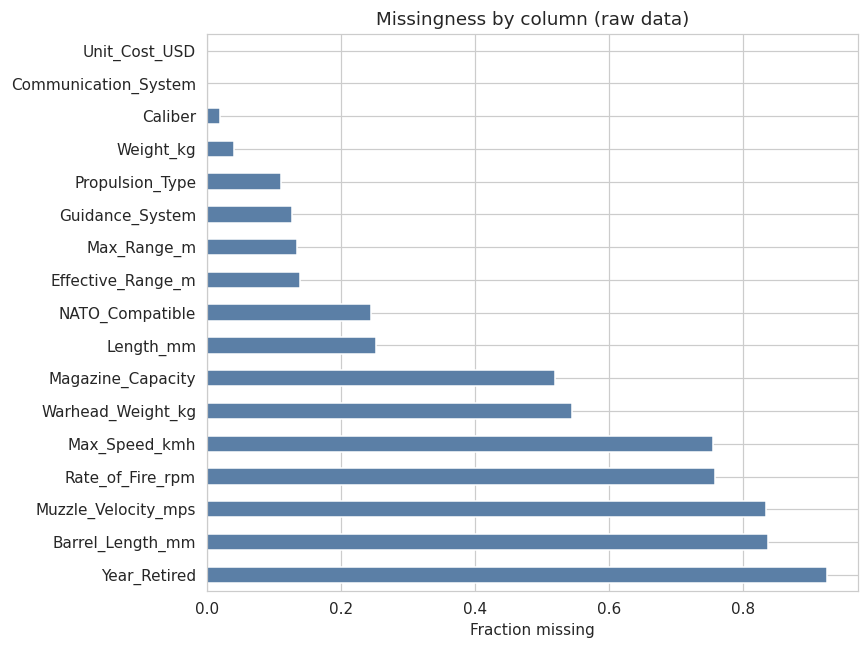

In [3]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 6))
missing.plot(kind='barh', ax=ax, color='#5b7fa6')
ax.set_xlabel('Fraction missing')
ax.set_title('Missingness by column (raw data)')
plt.tight_layout()
plt.savefig('../reports/figures/missingness_by_column.png', dpi=150)
plt.show()


**Observation.** Several fields are missing 50-93% of the time
(`Year_Retired`, `Barrel_Length_mm`, `Muzzle_Velocity_mps`, `Rate_of_Fire_rpm`,
`Max_Speed_kmh`, `Warhead_Weight_kg`). Naive median imputation across the
whole column would be wrong here — see Section 4, where we show this
missingness is *structural*, not random, and therefore informative.


## 2. Target Distribution

Checking class balance up front determines whether accuracy is a safe
metric and whether stratified splitting / class weighting is needed.


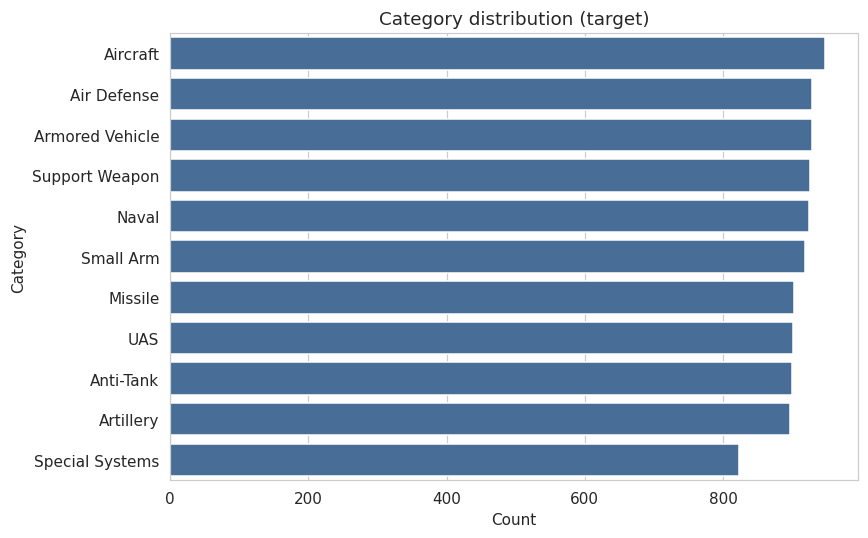

Category
Aircraft           948
Air Defense        929
Armored Vehicle    929
Support Weapon     926
Naval              925
Small Arm          918
Missile            903
UAS                902
Anti-Tank          900
Artillery          897
Special Systems    823
Name: count, dtype: int64

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df['Category'].value_counts().index
sns.countplot(data=df, y='Category', order=order, ax=ax, color='#3b6ea5')
ax.set_title('Category distribution (target)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150)
plt.show()

df['Category'].value_counts()


**Observation.** All 11 classes fall in a narrow 823-948 row band (8.2%-9.5%
of the data each) — essentially balanced. **Consequence:** accuracy would
not be badly misleading here, but `src/train.py` still selects models by
macro-F1 on principle (equal weight per class regardless of support), since
that is the more defensible default for multi-class problems in general and
costs nothing when classes happen to be balanced.


## 3. Leakage Audit — the critical section

Two columns require scrutiny before they are allowed anywhere near the
feature set: `Notes` (free text) and `Subcategory` (a finer-grained label).


In [5]:
print('Sample Notes values:')
for n in df['Notes'].sample(6, random_state=1):
    print(' -', n)


Sample Notes values:
 - 5th generation Self-Propelled AA Vehicle; operated by Zimbabwe; active service; All-terrain optimised
 - 4.5th generation Self-Propelled Howitzer; operated by Greece; reserve service; Jungle optimised
 - 1st generation CBRN Detection System; operated by Armenia; reserve service; Mountain optimised
 - 1st generation Counter-UAS System; operated by Colombia; reserve service; Desert optimised
 - 3rd generation Anti-Tank Mine Layer; operated by Norway; active (limited) service; Amphibious optimised
 - 3.5th generation Maritime Patrol Aircraft; operated by Libya; retired service; Mountain optimised


**Finding:** `Notes` is generated from a template of the form
`"<Generation> generation <Subcategory>; operated by <Country>; <status>
service; <Environment> optimised"` — it literally contains the
`Subcategory` string as a substring. Any text feature built from `Notes`
(bag-of-words, TF-IDF, embeddings) would let the model read the answer
directly off the page.


In [6]:
# Does Subcategory determine Category?
mapping_purity = df.groupby('Subcategory')['Category'].nunique()
print(f"Subcategories mapping to exactly one Category: {(mapping_purity == 1).sum()} / {len(mapping_purity)}")
print(f"Subcategories mapping to >1 Category: {(mapping_purity > 1).sum()}")


Subcategories mapping to exactly one Category: 140 / 141
Subcategories mapping to >1 Category: 1


**Finding:** 140 of 141 subcategories map to exactly one parent `Category`.
Knowing `Subcategory` is therefore equivalent to knowing `Category` almost
everywhere — a second, more direct leakage path (and note that `Notes`
leaks `Subcategory`, which leaks `Category`: a two-hop leak).

**Decision (encoded in `config.yaml: task.leakage_columns`):** `Notes`,
`Subcategory`, and `Weapon_Name` (many names literally contain category
words like "Carbine", "Tank", "Frigate" — a softer, partial leak) are
excluded from the feature set used in `src/features.py`. `ID` is dropped
as a non-predictive row identifier.


## 4. Missingness Is Structural, Not Random

A field like `Warhead_Weight_kg` being null is not a data-collection
accident — a rifle does not have a warhead. This section verifies that
missingness patterns are category-specific and therefore a legitimate
engineered feature (see `add_missingness_indicators` in
`src/preprocessing.py`), which must be added **before** imputation or the
signal is destroyed.


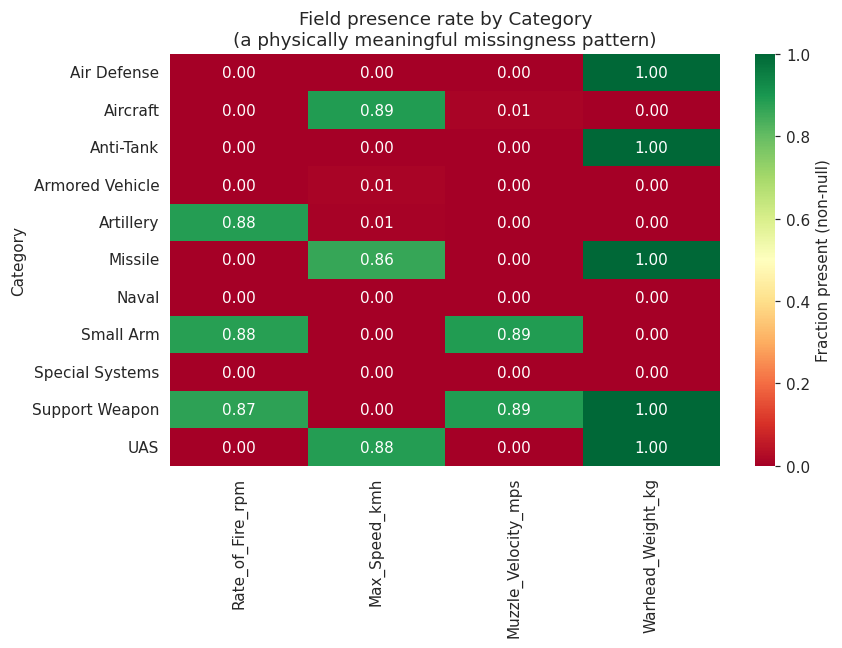

In [7]:
structural_cols = ['Rate_of_Fire_rpm', 'Max_Speed_kmh', 'Muzzle_Velocity_mps', 'Warhead_Weight_kg']
presence_by_cat = df.groupby('Category')[structural_cols].apply(lambda x: x.notnull().mean())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(presence_by_cat, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'Fraction present (non-null)'}, ax=ax)
ax.set_title('Field presence rate by Category\n(a physically meaningful missingness pattern)')
plt.tight_layout()
plt.savefig('../reports/figures/structural_missingness.png', dpi=150)
plt.show()


**Observation.** `Warhead_Weight_kg` is populated ~99.7-100% of the time
for Air Defense, Anti-Tank, Missile, Support Weapon, and UAS rows, and
essentially 0% for Aircraft, Armored Vehicle, Naval, Small Arm, and
Special Systems — an almost perfect split that mirrors which weapon types
physically carry a distinct warhead. Similarly `Rate_of_Fire_rpm` is
populated for Artillery/Small Arm/Support Weapon (~87-88%) and near-zero
elsewhere.

**Consequence:** `preprocessing.add_missingness_indicators()` creates a
`<column>_is_missing` binary flag for every structurally-missing numeric
column *before* imputation. These flags alone carry strong class signal.


## 5. Class Separability — why the classifier will score so high

Before training anything, it's worth checking how deterministic a few
categorical fields are with respect to the target. High purity here is a
prior signal that classification will be easy — worth knowing *before*
seeing a suspiciously perfect test score, so it isn't mistaken for a bug.


In [8]:
def weighted_purity(col):
    ct = pd.crosstab(df[col], df['Category'])
    purity = ct.max(axis=1) / ct.sum(axis=1)
    return (purity * ct.sum(axis=1)).sum() / ct.sum(axis=1).sum()

for col in ['Action_Type', 'Caliber', 'Propulsion_Type', 'Guidance_System', 'Operating_Environment']:
    print(f'{col:22s} n_unique={df[col].nunique():4d}  weighted top-category purity={weighted_purity(col):.3f}')


Action_Type            n_unique=  85  weighted top-category purity=0.977
Caliber                n_unique= 153  weighted top-category purity=0.891
Propulsion_Type        n_unique=  58  weighted top-category purity=0.606
Guidance_System        n_unique=  50  weighted top-category purity=0.496
Operating_Environment  n_unique=  12  weighted top-category purity=0.110


**Observation.** `Action_Type` alone has ~85 distinct values, and on
average 97.7% of the rows sharing a given `Action_Type` value belong to a
*single* `Category` (e.g. "Gas-operated short stroke piston" is
overwhelmingly Small Arm). `Caliber` shows a similar 89% weighted purity.
This strongly suggests the dataset's categorical fields were generated
**conditionally on Category** — consistent with the templated-`Notes`
finding in Section 3, and telling us this is a synthetic dataset whose
generative process encodes the label into many columns simultaneously,
not just the two we already excluded.

**Consequence — an honest limitation, not just a caveat:** a model
trained on this data will likely reach near-ceiling accuracy quickly.
That is a genuine finding about *this dataset's generative structure*,
not evidence of strong generalizable domain knowledge. A classifier
trained here should not be assumed to generalize to real-world weapons
specs sourced from a different (non-templated) process — see
`reports/model_card.md` -> Limitations.


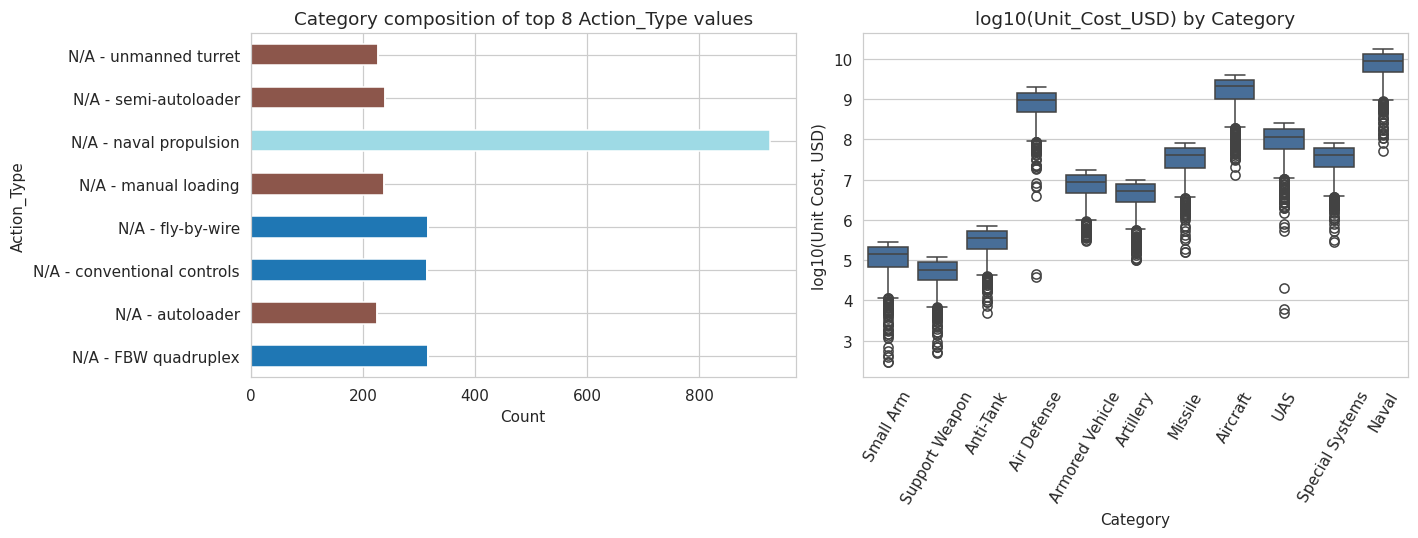

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_action = df['Action_Type'].value_counts().head(8).index
sub = df[df['Action_Type'].isin(top_action)]
ct = pd.crosstab(sub['Action_Type'], sub['Category'])
ct.plot(kind='barh', stacked=True, ax=axes[0], legend=False, colormap='tab20')
axes[0].set_title('Category composition of top 8 Action_Type values')
axes[0].set_xlabel('Count')

sns.boxplot(data=df, x='Category', y=np.log10(df['Unit_Cost_USD'].clip(lower=1)), ax=axes[1], color='#3b6ea5')
axes[1].set_title('log10(Unit_Cost_USD) by Category')
axes[1].tick_params(axis='x', rotation=60)
axes[1].set_ylabel('log10(Unit Cost, USD)')
plt.tight_layout()
plt.savefig('../reports/figures/separability_evidence.png', dpi=150)
plt.show()


`Unit_Cost_USD` (right panel) is the single strongest *numeric* feature at
model-evaluation time (see `reports/figures/permutation_importance.png`):
Small Arms and Anti-Tank systems cluster orders of magnitude below Naval
and Aircraft systems, giving a coarse but useful prior even before any
categorical feature is consulted.


## 6. Conclusions, Limitations, and What This Means for Modeling

**Conclusions**
- The dataset is a hybrid of a small set of real systems and a much
  larger body of synthetic, templated rows.
- The target (`Category`, 11 classes) is balanced; macro-F1 is used for
  model selection on principle.
- `Notes` and `Subcategory` leak the label directly and are excluded, along
  with `Weapon_Name` (partial leak) and `ID` (non-predictive).
- Missingness in several numeric fields is structural (physically
  meaningful) rather than random, and is preserved as explicit binary
  indicator features rather than being erased by imputation.
- Multiple categorical fields (`Action_Type`, `Caliber`, ...) are highly
  predictive of `Category` almost by construction, which means the
  downstream classifier (see `models/metrics.json`) will score very
  close to ceiling. This is reported as a property of the dataset, not
  oversold as a demonstration of hard-won model skill.

**Limitations**
- With near-perfect separability, this notebook cannot distinguish
  "the model learned real physical relationships" from "the model learned
  the data generator's template." Both produce identical held-out
  metrics.
- Absolute values (cost, range, speed) for the synthetic majority of rows
  should not be treated as real-world weapons intelligence.
- No temporal validation was performed (e.g. train on pre-2015 systems,
  test on post-2015) — with more heterogeneous / real-world data, this
  would be a more realistic generalization test than a random split.

**Future work**
- If a non-templated real-world dataset becomes available, re-run the
  leakage and separability audits from scratch — do not assume the same
  columns are safe.
- Try predicting `Subcategory` (141 classes) as a harder, more granular
  task once `Notes`-derived leakage is controlled for.
- Add a text-based baseline using `Weapon_Name` alone (fully expecting
  partial leakage) as a lower-bound sanity check, reported separately
  from the leakage-free structured model.
